In [3]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [5]:
# Load the CSV file
df = pd.read_csv('../data/sales_data.csv')

# Check the data
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (500, 7)

Columns: ['Order_ID', 'Product_Category', 'Region', 'Order_Quantity', 'Unit_Price', 'Revenue', 'Month']

First 5 rows:


,Order_ID,Product_Category,Region,Order_Quantity,Unit_Price,Revenue,Month
0,1,Books,South,2,155.19,2974.38,Apr
1,2,Sports,West,15,124.47,923.27,Jun
2,3,Food,West,8,30.63,3710.68,Aug
3,4,Sports,North,8,18.76,4327.71,Aug
4,5,Sports,South,17,493.98,1162.03,May


In [6]:
# Create SQLite database
conn = sqlite3.connect('../data/sales_database.db')

# Save dataframe to database
df.to_sql('sales', conn, if_exists='replace', index=False)

print("Data saved to SQLite database successfully!")
print(f"Total records: {len(df)}")

Data saved to SQLite database successfully!
Total records: 500


In [7]:
# Query 1: Total sales by product category
query1 = """
SELECT Product_Category, 
       SUM(Order_Quantity) as Total_Quantity,
       ROUND(SUM(Revenue), 2) as Total_Revenue
FROM sales
GROUP BY Product_Category
ORDER BY Total_Revenue DESC
"""

result1 = pd.read_sql_query(query1, conn)
print("Sales by Product Category:")
print(result1)

Sales by Product Category:
  Product_Category  Total_Quantity  Total_Revenue
0            Books            1088      276414.89
1      Electronics            1157      266632.60
2         Clothing             866      243651.65
3           Sports             996      235635.78
4             Food             779      234308.52


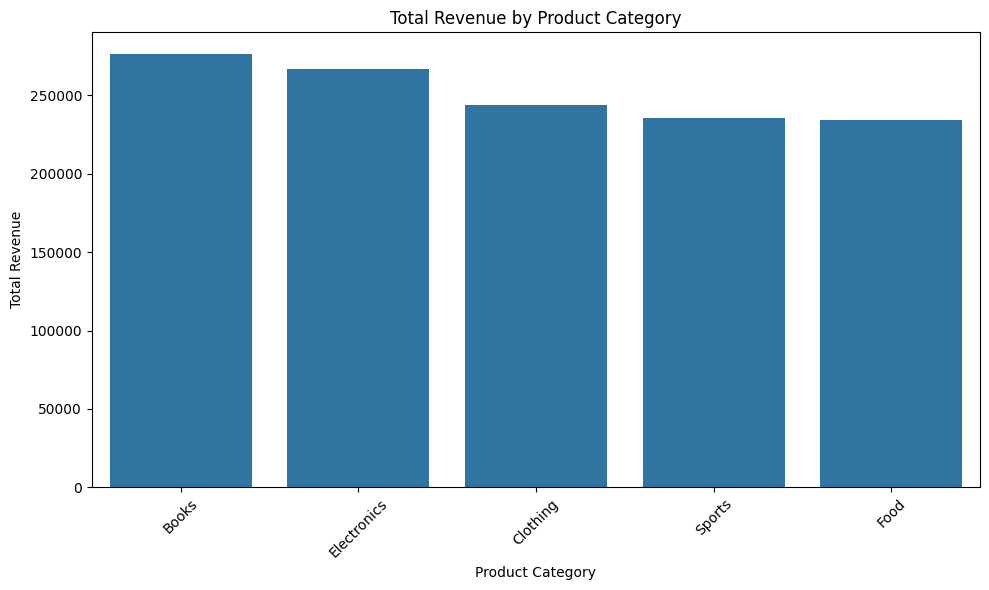

Chart saved to outputs folder!


In [8]:
# Chart 1: Revenue by Product Category
plt.figure(figsize=(10, 6))
sns.barplot(data=result1, x='Product_Category', y='Total_Revenue')
plt.title('Total Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/revenue_by_category.png')
plt.show()
print("Chart saved to outputs folder!")

Sales by Region:
  Region  Total_Orders  Total_Revenue
0  North           143      344931.97
1   East           124      329183.66
2  South           125      319739.20
3   West           108      262788.61


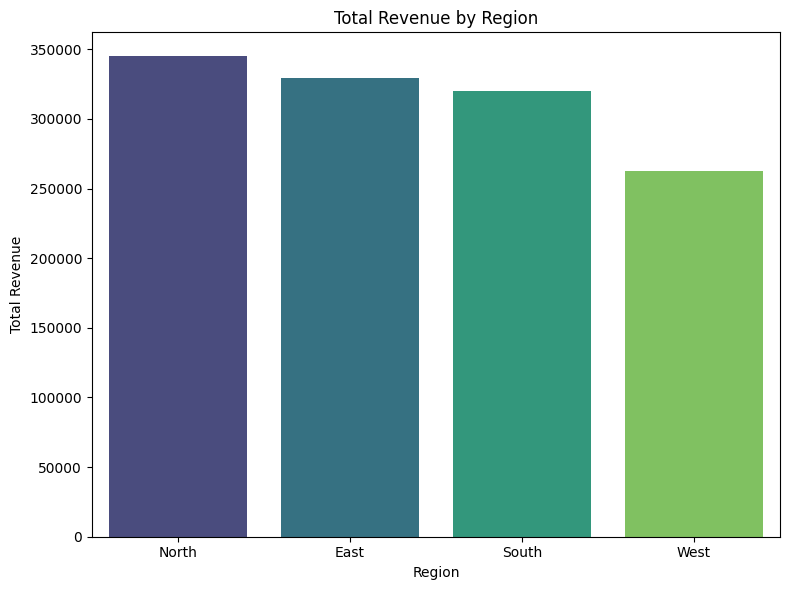

Chart saved!


In [10]:
# Query 2: Sales by Region
query2 = """
SELECT Region,
       COUNT(*) as Total_Orders,
       ROUND(SUM(Revenue), 2) as Total_Revenue
FROM sales
GROUP BY Region
ORDER BY Total_Revenue DESC
"""

result2 = pd.read_sql_query(query2, conn)
print("Sales by Region:")
print(result2)

# Chart 2: Revenue by Region
plt.figure(figsize=(8, 6))
sns.barplot(data=result2, x='Region', y='Total_Revenue', palette='viridis')
plt.title('Total Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.savefig('../outputs/revenue_by_region.png')
plt.show()
print("Chart saved!")

Monthly Revenue:
   Month  Monthly_Revenue  Total_Orders
0    Dec        140131.07            55
1    Aug        135628.78            49
2    Sep        126351.41            50
3    Mar        124281.68            50
4    May        110806.60            40
5    Jan         98591.71            41
6    Jul         93217.51            38
7    Apr         91217.79            41
8    Nov         88435.10            38
9    Jun         87042.01            38
10   Feb         82597.46            34
11   Oct         78342.32            26


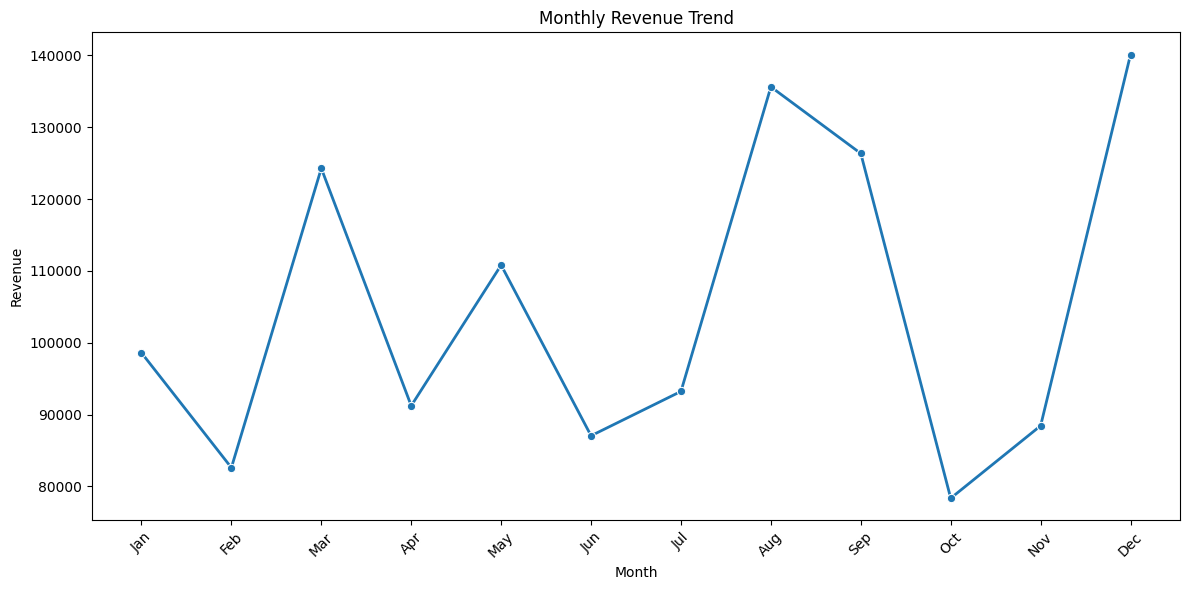

Chart saved!


In [11]:
# Query 3: Monthly Revenue Trend
query3 = """
SELECT Month,
       ROUND(SUM(Revenue), 2) as Monthly_Revenue,
       COUNT(*) as Total_Orders
FROM sales
GROUP BY Month
ORDER BY Monthly_Revenue DESC
"""

result3 = pd.read_sql_query(query3, conn)
print("Monthly Revenue:")
print(result3)

# Chart 3: Monthly Revenue
plt.figure(figsize=(12, 6))
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
result3['Month'] = pd.Categorical(result3['Month'], categories=month_order, ordered=True)
result3 = result3.sort_values('Month')
sns.lineplot(data=result3, x='Month', y='Monthly_Revenue', marker='o', linewidth=2)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/monthly_trend.png')
plt.show()
print("Chart saved!")

In [12]:
# Close database connection
conn.close()

print("="*40)
print("PROJECT SUMMARY")
print("="*40)
print(f"Total Records Analysed: {len(df)}")
print(f"Total Revenue: ${df['Revenue'].sum():,.2f}")
print(f"Average Order Value: ${df['Revenue'].mean():,.2f}")
print(f"Top Product Category: {result1.iloc[0]['Product_Category']}")
print(f"Top Region: {result2.iloc[0]['Region']}")
print("="*40)
print("\nAll charts saved to outputs/ folder!")
print("Project Complete!")

PROJECT SUMMARY
Total Records Analysed: 500
Total Revenue: $1,256,643.44
Average Order Value: $2,513.29
Top Product Category: Books
Top Region: North

All charts saved to outputs/ folder!
Project Complete!
